# 3Q QST Test (Product-State Canonical API)

This notebook exercises the canonical product-state 3Q workflow:

- `qubit_experiment.experiments.three_qubit_readout_calibration`
- `qubit_experiment.experiments.threeq_qst`
- `qubit_experiment.analysis.threeq_qst`

It assumes your hardware context already provides `setup`, `qpu`, `qubits`, and `buses`.


In [ ]:
# Core imports + repo bootstrap
%run ../scripts/bootstrap_notebook.py

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from laboneq.simple import Session
from qubit_experiment.analysis import threeq_qst as threeq_qst_analysis
from qubit_experiment.experiments import three_qubit_readout_calibration, threeq_qst

print(f"Using project root: {PROJECT_ROOT}")


## Init

Set qubit/bus indices for your device mapping.


In [2]:
import numpy as np
from pprint import pprint
from copy import deepcopy
import sys
from pathlib import Path


from laboneq.contrib.example_helpers.generate_descriptor import generate_descriptor
#from laboneq.contrib.example_helpers.generate_device_setup import generate_device_setup
from laboneq.dsl.device import DeviceSetup
from laboneq.simple import *
from laboneq.dsl.device import DeviceSetup
from laboneq.dsl.calibration import Oscillator, SignalCalibration
from laboneq.dsl.enums import ModulationType




# descriptor = generate_descriptor(
#     #pqsc=[""], # 장비 여러개 사용시
#     shfqc_6=["DEV12256"], 
#     number_data_qubits=3,
#     multiplex=True,
#     number_multiplex=6,
#     include_cr_lines=False,
#     include_ef_lines=True,
#     get_zsync=False,  # Only set to True when using real device
#     save = True,
#     filename="1port",
#     ip_address="192.168.0.83"
# )


#descriptor
#setup = DeviceSetup.from_descriptor(yaml_text=descriptor, server_host="192.168.0.83")
descriptor_candidates = [
    Path("configs/descriptors/1port.yaml"),
    Path("configs/descriptors/1port.yaml"),
]
descriptor_path = next((p for p in descriptor_candidates if p.exists()), descriptor_candidates[0])
setup = DeviceSetup.from_yaml(filepath=str(descriptor_path.resolve()), server_host="192.168.0.83")
#setup
setup.instruments[0].device_options = 'SHFQC/PLUS/QC6CH'
#setup.instruments


bus_ids = [f"b{i}" for i in range(3)]
bus_port = [3,4,5] #used 1,2,3 for qubit drive

for i, bus in zip(bus_port,bus_ids):
    setup.add_connections(
        setup.instruments[0].uid,
        # each bus uses its own drive:
        create_connection(
            to_signal=f"{bus}/drive",
            ports=f"SGCHANNELS/{i}/OUTPUT"
        ))

# Calibrate qubit drive/measure lines for oscillator phase increments
qubit_ids = [uid for uid in setup.logical_signal_groups if uid.startswith("q")]
for qubit in qubit_ids:
    for line, frequency, mod_type in [
        ("drive", 5e9, ModulationType.HARDWARE),
        ("drive_ef", 6e9, ModulationType.HARDWARE),
        ("measure", 4e9, ModulationType.SOFTWARE),
    ]:
        logical_signal = setup.logical_signal_by_uid(f"{qubit}/{line}")
        oscillator = Oscillator(modulation_type=mod_type)
        logical_signal.calibration = SignalCalibration(
            local_oscillator=Oscillator(frequency=frequency),
            oscillator=oscillator,
        )
        if line == "measure":
            acquire_signal = setup.logical_signal_by_uid(f"{qubit}/acquire")
            acquire_signal.calibration = SignalCalibration(
                local_oscillator=Oscillator(frequency=frequency),
                oscillator=oscillator,
            )

project_root = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / "qpu_types").exists() and (p / "helper.py").exists()),
    Path.cwd(),
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from qpu_types.fixed_transmon import FixedTransmonQubit, FixedTransmonQubitParameters
from qpu_types.bus_cavity import BusCavity, BusCavityParameters
from qpu_types.fixed_transmon.operations import FixedTransmonOperations
from qpu_types.bus_cavity.operations import BusCavityOperations
from laboneq.dsl.quantum.qpu import QPU, QuantumPlatform
from helper import load_qubit_parameters, save_qubit_parameters

qubit_uids = [uid for uid in setup.logical_signal_groups if uid.startswith("q")]
bus_uids = [uid for uid in setup.logical_signal_groups if uid.startswith("b")]

qubits = FixedTransmonQubit.from_device_setup(
    setup, qubit_uids=qubit_uids)
buses = BusCavity.from_device_setup(
    setup, qubit_uids=bus_uids)

qpu = QPU(quantum_elements={"qubits" : qubits, "bus" : buses}, quantum_operations=[FixedTransmonOperations, BusCavityOperations])


# from laboneq.simple import workflow
# folder_store = workflow.logbook.FolderStore("./experiment_store") 
# folder_store.activate()
# #folder_store.deactivate()
# #workflow.logbook.LoggingStore().activate()
# #workflow.logbook.LogbookStore().deactivate()

import os
from datetime import datetime
def find_latest_json(folder_path):
    files = [f for f in os.listdir(folder_path)]
    timestamps = []
    for file in files:
        try:
            # Extract a timestamp assuming it's included in the filename
            timestamp_str = file.split('_', 1)[0]  # Assuming YYYYMMDDHHMMSS format
            timestamp = datetime.strptime(timestamp_str, '%Y%m%d-%H%M%S')
            timestamps.append((timestamp, file))
        except ValueError:
            print("fuck")
            continue  # Skip files that do not match the timestamp format

       # Find the most recent file
    if timestamps:
        latest_file = max(timestamps, key=lambda x: x[0])[1]
        return os.path.join(folder_path, latest_file)
    return None

qb_pars_file = find_latest_json("./qpu_parameters/")
print(f"LOADED: {qb_pars_file}")

from qpu_types.fixed_transmon.operations import FixedTransmonOperations
from qpu_types.bus_cavity.operations import BusCavityOperations
import laboneq.dsl.quantum.qpu as qpu_mod

class CombinedOperations(FixedTransmonOperations, BusCavityOperations):
    pass

qpu_mod.CombinedOperations = CombinedOperations

qpu = load(qb_pars_file)

buses = qpu.groups.bus
qubits = qpu.groups.qubits


from laboneq.simple import workflow
folder_store = workflow.logbook.FolderStore("./experiment_store")
folder_store.activate()


fuck
LOADED: ./qpu_parameters/20260303-0824_3Q_tomo


In [3]:
# Connect session (skip if already connected)
if "session" not in globals() or session is None:
    session = Session(setup)
    session.connect(ignore_version_mismatch=False, do_emulation=False)

session


[2026.03.03 08:46:01.172] INFO    Logging initialized from [Default inline config in laboneq.laboneq_logging] logdir is laboneq_output/log
[2026.03.03 08:46:01.173] INFO    VERSION: laboneq 25.10.3
[2026.03.03 08:46:01.174] INFO    Connecting to data server at 192.168.0.83:8004
[2026.03.03 08:46:01.217] INFO    Connected to Zurich Instruments LabOne Data Server version 25.10.1.4 at 192.168.0.83:8004
[2026.03.03 08:46:01.263] INFO    Configuring the device setup
[2026.03.03 08:46:01.297] INFO    The device setup is configured


## Optional bus configuration

Update LO frequencies as needed for your calibration state.


## 3Q Readout Calibration

Run once and reuse for tomography sweeps.


In [4]:
spec = qubits[1]
ctrl = qubits[0]
targ = qubits[2]



qubits[0].parameters.readout_integration_delay=170e-9
qubits[1].parameters.readout_integration_delay=170e-9
qubits[2].parameters.readout_integration_delay=170e-9
qubits[0].parameters.readout_length=1.8e-6
qubits[1].parameters.readout_length=1.8e-6
qubits[2].parameters.readout_length=1.8e-6

In [5]:
RUN_READOUT_CALIBRATION = True

if RUN_READOUT_CALIBRATION:
    readout_cal_result_3q = three_qubit_readout_calibration.experiment_workflow(
        session=session,
        qpu=qpu,
        qubits=[spec, ctrl, targ],
    ).run()
else:
    print("Skipping calibration run. Reusing existing readout_cal_result_3q.")


[2026.03.03 08:46:01.856] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.03.03 08:46:01.857] INFO      Workflow 'three_qubit_readout_calibration': execution started at 2026-03-02   
[2026.03.03 08:46:01.857] INFO      23:46:01.856111Z                                                              
[2026.03.03 08:46:01.858] INFO     ────────────────────────────────────────────────────────────────────────────── 
[2026.03.03 08:46:01.865] INFO    Task 'temporary_qpu': started at 2026-03-02 23:46:01.865462Z
[2026.03.03 08:46:01.868] INFO    Task 'temporary_qpu': ended at 2026-03-02 23:46:01.868570Z
[2026.03.03 08:46:01.872] INFO    Task 'temporary_quantum_elements_from_qpu': started at 2026-03-02 
[2026.03.03 08:46:01.873] INFO    23:46:01.872696Z
[2026.03.03 08:46:01.874] INFO    Task 'temporary_quantum_elements_from_qpu': ended at 2026-03-02 23:46:01.874189Z
[2026.03.03 08:46:01.877] INFO    Task 'create_experiment': started at 2026-03-02 23:

## 3Q Tomography Run


In [ ]:
if "readout_cal_result_3q" not in globals():
    raise RuntimeError("readout_cal_result_3q not found. Run calibration cell first.")
if "temporary_parameters" not in globals():
    temporary_parameters = {}

opts = threeq_qst.experiment_workflow.options()
opts.do_readout_calibration(False)
opts.do_analysis(True)
opts.initial_state("+++")
opts.custom_prep(False)

analysis_options = threeq_qst_analysis.analysis_workflow.options()
analysis_options.do_plotting(True)

threeq_qst_output = threeq_qst.run_bundle(
    session=session,
    qpu=qpu,
    qubits=[spec, ctrl, targ],
    bus=[buses[0], buses[1], buses[2]],
    readout_calibration_result=readout_cal_result_3q,
    target_state="+++",
    temporary_parameters=temporary_parameters,
    options=opts,
    analysis_options=analysis_options,
)

analysis_output_3q = threeq_qst_output["analysis_result"]


## Result Inspection

`threeq_qst.run_bundle(...)` returns a plain Python dictionary, so no workflow graph traversal is needed in the notebook.


In [ ]:
if not isinstance(threeq_qst_output, dict):
    raise TypeError(f"Expected threeq_qst_output to be a dict, got {type(threeq_qst_output)!r}.")

analysis_output_3q = threeq_qst_output.get("analysis_result")
if not isinstance(analysis_output_3q, dict):
    raise TypeError(
        f"Expected analysis_result to be a dict, got {type(analysis_output_3q)!r}."
    )

print("Workflow output keys:", list(threeq_qst_output.keys()))
print("Analysis output keys:", list(analysis_output_3q.keys()))
analysis_output_3q


## Quick Metrics + Density Matrix Preview


trace: 1.0
purity: 0.5289994064910174
min_eigenvalue: 1.6705478040557304e-05
fidelity_to_target: 0.1650841094197482


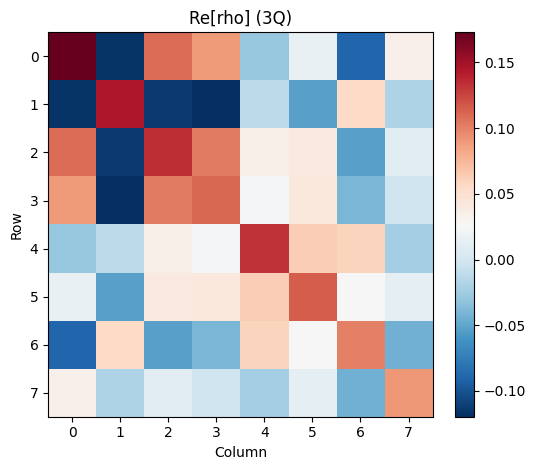

In [8]:
if not isinstance(analysis_output_3q, dict):
    raise RuntimeError("analysis_output_3q is not a dictionary. Check workflow execution.")

metrics = analysis_output_3q.get("metrics", {})
print("trace:", metrics.get("trace"))
print("purity:", metrics.get("purity"))
print("min_eigenvalue:", metrics.get("min_eigenvalue"))
print("fidelity_to_target:", metrics.get("fidelity_to_target"))

if "rho_hat_real" not in analysis_output_3q:
    raise RuntimeError(f"analysis_output_3q missing rho_hat_real. keys={sorted(analysis_output_3q.keys())}")

rho_real = np.asarray(analysis_output_3q["rho_hat_real"], dtype=float)
plt.figure(figsize=(5.5, 4.8))
plt.imshow(rho_real, cmap="RdBu_r")
plt.colorbar(fraction=0.046)
plt.title("Re[rho] (3Q)")
plt.xlabel("Column")
plt.ylabel("Row")
plt.tight_layout()
plt.show()


## Optional Shot Sweep (Product-State Suite)

Run this to check target-state infidelity versus shot count.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qubit_experiment.experiments.three_qubit_tomography_common import (
    canonical_three_qubit_state_label,
)

np.random.seed(20260222)

SHOT_LOG2_VALUES = list(range(3, 13))
SHOT_COUNTS = [2 ** k for k in SHOT_LOG2_VALUES]

# User-editable product-state suite.
product_state_suite = ["000", "111", "+++", "---"]
if not product_state_suite:
    raise ValueError("product_state_suite cannot be empty.")

canonical_states = []
_seen = set()
for raw_state in product_state_suite:
    canonical = canonical_three_qubit_state_label(raw_state)
    if canonical not in _seen:
        _seen.add(canonical)
        canonical_states.append(canonical)

PRODUCT_STATE_SUITE_STATES = tuple(canonical_states)
if not PRODUCT_STATE_SUITE_STATES:
    raise ValueError("No valid states in product_state_suite after canonicalization.")

if len(PRODUCT_STATE_SUITE_STATES) < len(product_state_suite):
    print(
        "Duplicate states were removed after canonicalization.",
        "Using:",
        PRODUCT_STATE_SUITE_STATES,
    )

REPEATS_PER_POINT = 3
EPS = 1e-12
INFID_TOL = 1e-9

expected_total_runs = (
    len(PRODUCT_STATE_SUITE_STATES) * len(SHOT_COUNTS) * REPEATS_PER_POINT
)

print("shot grid (log2):", SHOT_LOG2_VALUES)
print("shot counts:", SHOT_COUNTS)
print("states:", PRODUCT_STATE_SUITE_STATES)
print("repeats per point:", REPEATS_PER_POINT)
print("expected total runs:", expected_total_runs)


In [ ]:
if "temporary_parameters" not in globals():
    temporary_parameters = {}
if "spec" not in globals() or "ctrl" not in globals() or "targ" not in globals():
    spec = qubits[1]
    ctrl = qubits[0]
    targ = qubits[2]
if "bus_sweep" not in globals():
    bus_sweep = [buses[0], buses[1], buses[2]]


def _unwrap_result_like_local(result_like):
    current = result_like
    for _ in range(24):
        if current is None:
            return None
        if hasattr(current, "output"):
            current = current.output
            continue
        if isinstance(current, dict):
            if "readout_calibration_result" in current:
                current = current["readout_calibration_result"]
                continue
            if "result" in current:
                current = current["result"]
                continue
            if "tomography_result" in current:
                current = current["tomography_result"]
                continue
        return current
    return current


def _to_float_or_nan(value):
    try:
        v = float(value)
        return v if np.isfinite(v) else np.nan
    except Exception:
        return np.nan


# Reuse existing readout calibration if available; otherwise build it once.
readout_cal_for_sweep = _unwrap_result_like_local(globals().get("readout_cal_result_3q"))
if readout_cal_for_sweep is None:
    print("readout_cal_result_3q missing/invalid; running readout calibration once for sweep.")
    readout_cal_for_sweep = three_qubit_readout_calibration.experiment_workflow(
        session=session,
        qpu=qpu,
        qubits=[spec, ctrl, targ],
        temporary_parameters=temporary_parameters,
    ).run()
    readout_cal_for_sweep = _unwrap_result_like_local(readout_cal_for_sweep)

if readout_cal_for_sweep is None:
    raise RuntimeError("Failed to materialize readout calibration result for sweep analysis.")

# Keep a concrete payload for downstream cells.
readout_cal_result_3q = readout_cal_for_sweep

RUN_SHOT_SWEEP = True
sweep_rows = []
failed_runs = []
run_counter = 0
analysis_options_sweep = threeq_qst_analysis.analysis_workflow.options()
analysis_options_sweep.do_plotting(False)

if RUN_SHOT_SWEEP:
    for state in PRODUCT_STATE_SUITE_STATES:
        for log2_shots, shots in zip(SHOT_LOG2_VALUES, SHOT_COUNTS):
            for repeat in range(1, REPEATS_PER_POINT + 1):
                run_counter += 1
                print(
                    f"[{run_counter:03d}/{expected_total_runs}] "
                    f"state={state}, shots={shots}, repeat={repeat}"
                )

                tomo_opts_sweep = threeq_qst.experiment_workflow.options()
                tomo_opts_sweep.do_analysis(True)
                tomo_opts_sweep.do_readout_calibration(False)
                tomo_opts_sweep.initial_state(state)
                tomo_opts_sweep.custom_prep(False)
                tomo_opts_sweep.count(int(shots))

                try:
                    run_output = threeq_qst.run_bundle(
                        session=session,
                        qpu=qpu,
                        qubits=[spec, ctrl, targ],
                        bus=bus_sweep,
                        readout_calibration_result=readout_cal_for_sweep,
                        target_state=state,
                        options=tomo_opts_sweep,
                        analysis_options=analysis_options_sweep,
                        temporary_parameters=temporary_parameters,
                    )
                    analysis = run_output.get("analysis_result")
                except Exception as exc:
                    failed_runs.append(
                        {
                            "state": state,
                            "log2_shots": log2_shots,
                            "shots": shots,
                            "repeat": repeat,
                            "reason": repr(exc),
                        }
                    )
                    sweep_rows.append(
                        {
                            "state": state,
                            "log2_shots": log2_shots,
                            "shots": shots,
                            "repeat": repeat,
                            "fidelity": np.nan,
                            "infidelity": np.nan,
                            "log10_infidelity": np.nan,
                            "nll": np.nan,
                            "min_eig": np.nan,
                        }
                    )
                    print("  -> failed:", repr(exc))
                    continue

                metrics = analysis.get("metrics", {}) if isinstance(analysis, dict) else {}
                fid_raw = metrics.get("fidelity_to_target")
                nll_raw = (
                    analysis.get("negative_log_likelihood")
                    if isinstance(analysis, dict)
                    else np.nan
                )
                min_eig_raw = metrics.get("min_eigenvalue")

                fid = _to_float_or_nan(fid_raw)
                if np.isfinite(fid):
                    infid = max(EPS, 1.0 - fid)
                    log10_infid = float(np.log10(infid))
                else:
                    infid = np.nan
                    log10_infid = np.nan
                    failed_runs.append(
                        {
                            "state": state,
                            "log2_shots": log2_shots,
                            "shots": shots,
                            "repeat": repeat,
                            "reason": f"invalid fidelity: {fid_raw!r}",
                        }
                    )

                sweep_rows.append(
                    {
                        "state": state,
                        "log2_shots": log2_shots,
                        "shots": shots,
                        "repeat": repeat,
                        "fidelity": fid,
                        "infidelity": infid,
                        "log10_infidelity": log10_infid,
                        "nll": _to_float_or_nan(nll_raw),
                        "min_eig": _to_float_or_nan(min_eig_raw),
                    }
                )
else:
    print("RUN_SHOT_SWEEP=False -> sweep loop skipped.")

shot_sweep_df = pd.DataFrame(
    sweep_rows,
    columns=[
        "state",
        "log2_shots",
        "shots",
        "repeat",
        "fidelity",
        "infidelity",
        "log10_infidelity",
        "nll",
        "min_eig",
    ],
)

print("Completed rows:", len(shot_sweep_df))
print("Failed/invalid runs:", len(failed_runs))
if failed_runs:
    display(pd.DataFrame(failed_runs).head(10))

display(shot_sweep_df.head())


In [18]:
required_cols = [
    "state",
    "log2_shots",
    "shots",
    "repeat",
    "fidelity",
    "infidelity",
    "log10_infidelity",
    "nll",
    "min_eig",
]
assert list(shot_sweep_df.columns) == required_cols, "Unexpected dataframe schema."

counts_by_group = shot_sweep_df.groupby(["state", "log2_shots"]).size()
expected_index = pd.MultiIndex.from_product(
    [PRODUCT_STATE_SUITE_STATES, SHOT_LOG2_VALUES],
    names=["state", "log2_shots"],
)
missing_groups = expected_index.difference(counts_by_group.index)
bad_repeat_groups = counts_by_group[counts_by_group != REPEATS_PER_POINT]

range_violations = shot_sweep_df[
    shot_sweep_df["infidelity"].notna()
    & (
        (shot_sweep_df["infidelity"] < (EPS - 1e-15))
        | (shot_sweep_df["infidelity"] > (1.0 + INFID_TOL))
    )
]

print("=== Validation checks ===")
print("expected groups:", len(expected_index))
print("observed groups:", len(counts_by_group))
print("missing groups:", len(missing_groups))
print("groups with wrong repeat count:", len(bad_repeat_groups))
print("infidelity range violations:", len(range_violations))

counts_matrix = counts_by_group.unstack(level=1).reindex(PRODUCT_STATE_SUITE_STATES)
display(counts_matrix)

if len(missing_groups) > 0:
    print("Missing groups:", list(missing_groups)[:10])
if len(bad_repeat_groups) > 0:
    print("Bad repeat groups:")
    display(bad_repeat_groups)
if len(range_violations) > 0:
    print("Range violations (first 10):")
    display(range_violations.head(10))


=== Validation checks ===
expected groups: 40
observed groups: 40
missing groups: 0
groups with wrong repeat count: 0
infidelity range violations: 0


log2_shots,3,4,5,6,7,8,9,10,11,12
state,,,,,,,,,,
000,3,3,3,3,3,3,3,3,3,3
111,3,3,3,3,3,3,3,3,3,3
+++,3,3,3,3,3,3,3,3,3,3
---,3,3,3,3,3,3,3,3,3,3


In [19]:
def _finite_stats(series):
    arr = pd.to_numeric(series, errors="coerce").to_numpy(dtype=float)
    arr = arr[np.isfinite(arr)]
    n = arr.size
    if n == 0:
        return {
            "n": 0,
            "mean": np.nan,
            "std": np.nan,
            "sem": np.nan,
            "ci95": np.nan,
        }
    mean = float(np.mean(arr))
    std = float(np.std(arr, ddof=1)) if n > 1 else 0.0
    sem = float(std / np.sqrt(n)) if n > 1 else 0.0
    ci95 = float(1.96 * sem) if n > 1 else 0.0
    return {
        "n": int(n),
        "mean": mean,
        "std": std,
        "sem": sem,
        "ci95": ci95,
    }


agg_rows = []
for (state, log2_shots), group in shot_sweep_df.groupby(["state", "log2_shots"], sort=True):
    inf_stats = _finite_stats(group["infidelity"])
    log_stats = _finite_stats(group["log10_infidelity"])
    agg_rows.append(
        {
            "state": state,
            "log2_shots": int(log2_shots),
            "shots": int(group["shots"].iloc[0]),
            "n_total": int(len(group)),
            "n_valid_infidelity": inf_stats["n"],
            "infid_mean": inf_stats["mean"],
            "infid_std": inf_stats["std"],
            "infid_sem": inf_stats["sem"],
            "infid_ci95": inf_stats["ci95"],
            "log10_infid_mean": log_stats["mean"],
            "log10_infid_std": log_stats["std"],
            "log10_infid_sem": log_stats["sem"],
            "log10_infid_ci95": log_stats["ci95"],
        }
    )

shot_sweep_stats = pd.DataFrame(agg_rows).sort_values(["state", "log2_shots"]).reset_index(drop=True)
display(shot_sweep_stats.head(15))


,state,log2_shots,shots,n_total,n_valid_infidelity,infid_mean,infid_std,infid_sem,infid_ci95,log10_infid_mean,log10_infid_std,log10_infid_sem,log10_infid_ci95
0,+++,3,8,3,3,0.247976,0.056837,0.032815,0.064317,-0.613792,0.105282,0.060785,0.119138
1,+++,4,16,3,3,0.212975,0.032248,0.018619,0.036492,-0.675095,0.067314,0.038864,0.076173
2,+++,5,32,3,3,0.200717,0.006386,0.003687,0.007226,-0.697562,0.013858,0.008001,0.015682
3,+++,6,64,3,3,0.199969,0.016331,0.009429,0.018481,-0.699983,0.034954,0.020181,0.039555
4,+++,7,128,3,3,0.198901,0.004152,0.002397,0.004699,-0.701427,0.009122,0.005266,0.010322
5,+++,8,256,3,3,0.216728,0.007036,0.004062,0.007962,-0.664237,0.014057,0.008116,0.015906
6,+++,9,512,3,3,0.206132,0.002776,0.001603,0.003141,-0.685882,0.005855,0.003380,0.006626
7,+++,10,1024,3,3,0.209772,0.005513,0.003183,0.006238,-0.678354,0.011495,0.006636,0.013007
8,+++,11,2048,3,3,0.214804,0.001370,0.000791,0.001550,-0.667963,0.002768,0.001598,0.003133
9,+++,12,4096,3,3,0.216783,0.004164,0.002404,0.004712,-0.664029,0.008389,0.004843,0.009493


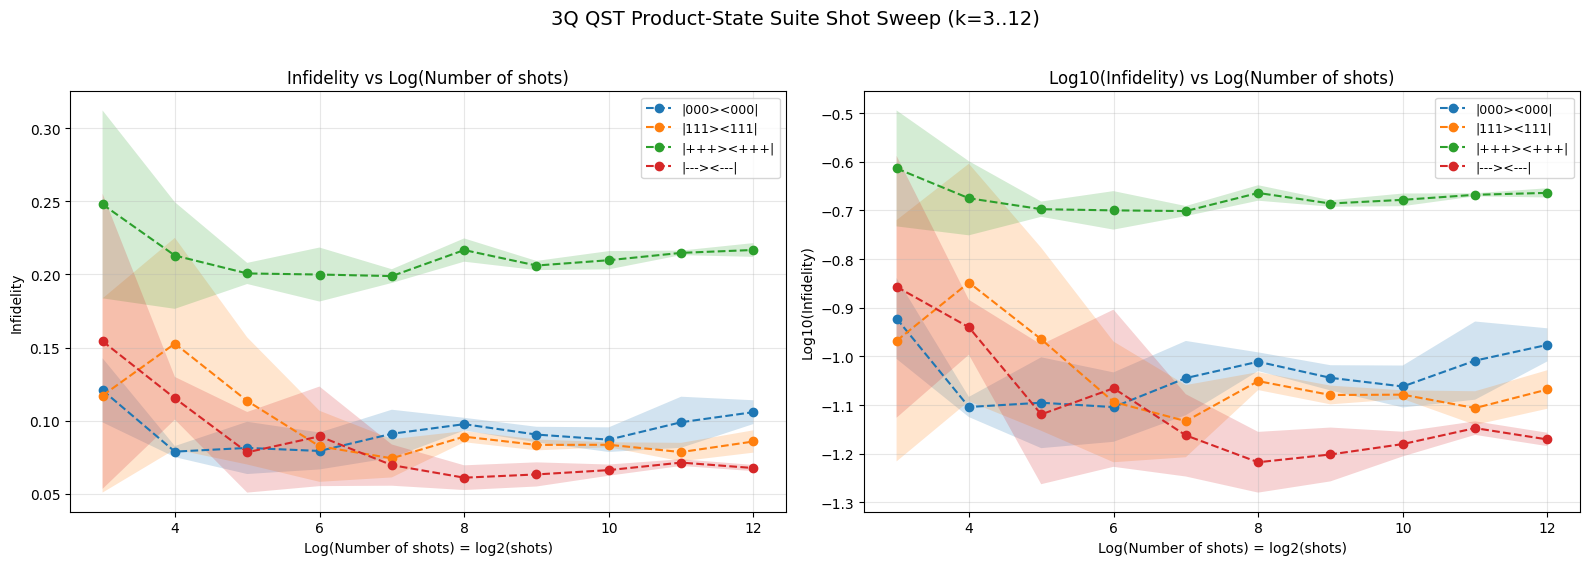

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

for state in PRODUCT_STATE_SUITE_STATES:
    state_df = shot_sweep_stats[shot_sweep_stats["state"] == state].sort_values("log2_shots")
    x = state_df["log2_shots"].to_numpy(dtype=float)

    y_infid = state_df["infid_mean"].to_numpy(dtype=float)
    e_infid = state_df["infid_ci95"].to_numpy(dtype=float)
    mask_infid = np.isfinite(y_infid)
    if np.any(mask_infid):
        axes[0].plot(x[mask_infid], y_infid[mask_infid], "o--", label=f"|{state}><{state}|")
        low = y_infid[mask_infid] - np.nan_to_num(e_infid[mask_infid], nan=0.0)
        high = y_infid[mask_infid] + np.nan_to_num(e_infid[mask_infid], nan=0.0)
        axes[0].fill_between(x[mask_infid], low, high, alpha=0.2)

    y_log = state_df["log10_infid_mean"].to_numpy(dtype=float)
    e_log = state_df["log10_infid_ci95"].to_numpy(dtype=float)
    mask_log = np.isfinite(y_log)
    if np.any(mask_log):
        axes[1].plot(x[mask_log], y_log[mask_log], "o--", label=f"|{state}><{state}|")
        low = y_log[mask_log] - np.nan_to_num(e_log[mask_log], nan=0.0)
        high = y_log[mask_log] + np.nan_to_num(e_log[mask_log], nan=0.0)
        axes[1].fill_between(x[mask_log], low, high, alpha=0.2)

axes[0].set_title("Infidelity vs Log(Number of shots)")
axes[0].set_xlabel("Log(Number of shots) = log2(shots)")
axes[0].set_ylabel("Infidelity")
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=9)

axes[1].set_title("Log10(Infidelity) vs Log(Number of shots)")
axes[1].set_xlabel("Log(Number of shots) = log2(shots)")
axes[1].set_ylabel("Log10(Infidelity)")
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=9)

fig.suptitle(
    f"3Q QST Product-State Suite Shot Sweep (k={min(SHOT_LOG2_VALUES)}..{max(SHOT_LOG2_VALUES)})",
    y=1.02,
    fontsize=14,
)
fig.tight_layout()
plt.show()


In [21]:
last_log2 = max(SHOT_LOG2_VALUES)
last_shots = 2 ** last_log2

if "shot_sweep_stats" not in globals():
    if "shot_sweep_df" not in globals():
        raise RuntimeError(
            "shot_sweep_stats is not defined and shot_sweep_df is also missing. "
            "Run the shot sweep collection cell first."
        )

    import numpy as np
    import pandas as pd

    def _finite_stats_local(series):
        arr = pd.to_numeric(series, errors="coerce").to_numpy(dtype=float)
        arr = arr[np.isfinite(arr)]
        n = arr.size
        if n == 0:
            return {
                "n": 0,
                "mean": np.nan,
                "std": np.nan,
                "sem": np.nan,
                "ci95": np.nan,
            }
        mean = float(np.mean(arr))
        std = float(np.std(arr, ddof=1)) if n > 1 else 0.0
        sem = float(std / np.sqrt(n)) if n > 1 else 0.0
        ci95 = float(1.96 * sem) if n > 1 else 0.0
        return {
            "n": int(n),
            "mean": mean,
            "std": std,
            "sem": sem,
            "ci95": ci95,
        }

    agg_rows = []
    for (state, log2_shots), group in shot_sweep_df.groupby(["state", "log2_shots"], sort=True):
        inf_stats = _finite_stats_local(group["infidelity"])
        log_stats = _finite_stats_local(group["log10_infidelity"])
        agg_rows.append(
            {
                "state": state,
                "log2_shots": int(log2_shots),
                "shots": int(group["shots"].iloc[0]),
                "n_total": int(len(group)),
                "n_valid_infidelity": inf_stats["n"],
                "infid_mean": inf_stats["mean"],
                "infid_std": inf_stats["std"],
                "infid_sem": inf_stats["sem"],
                "infid_ci95": inf_stats["ci95"],
                "log10_infid_mean": log_stats["mean"],
                "log10_infid_std": log_stats["std"],
                "log10_infid_sem": log_stats["sem"],
                "log10_infid_ci95": log_stats["ci95"],
            }
        )

    shot_sweep_stats = (
        pd.DataFrame(agg_rows)
        .sort_values(["state", "log2_shots"])
        .reset_index(drop=True)
    )
    print("Rebuilt `shot_sweep_stats` from `shot_sweep_df`.")

final_summary = (
    shot_sweep_stats[shot_sweep_stats["log2_shots"] == last_log2][
        [
            "state",
            "n_total",
            "n_valid_infidelity",
            "infid_mean",
            "infid_ci95",
            "log10_infid_mean",
            "log10_infid_ci95",
        ]
    ]
    .sort_values("state")
    .reset_index(drop=True)
)

print(f"Final-shot summary at log2(shots)={last_log2} (shots={last_shots})")
display(final_summary)


Final-shot summary at log2(shots)=12 (shots=4096)


,state,n_total,n_valid_infidelity,infid_mean,infid_ci95,log10_infid_mean,log10_infid_ci95
0,+++,3,3,0.216783,0.004712,-0.664029,0.009493
1,---,3,3,0.067510,0.002124,-1.170744,0.013756
2,000,3,3,0.105776,0.008130,-0.976296,0.033949
3,111,3,3,0.085687,0.007646,-1.068011,0.039580


## Save QPU Parameters (Optional)


In [23]:
from laboneq.serializers import save, load, from_dict, from_json, to_dict, to_json
import time

t = time.localtime()
timestamp = time.strftime('%Y%m%d-%H%M', t)

filename = "3Q_tomo"
save(qpu, filename=f"./qpu_parameters/{timestamp}_{filename}") 

